$\newcommand{\bR}{\mathbb{R}}
\newcommand{\bN}{\mathbb{N}}
\newcommand{\cF}{\mathcal{F}}
\newcommand{\cH}{\mathcal{H}}
\newcommand{\rmd}{\mathrm{d}}
\newcommand{\bfb}{\mathbf{b}}
\newcommand{\bfc}{\mathbf{c}}
\newcommand{\bfD}{\mathbf{D}}
\newcommand{\bfe}{\mathbf{e}}
\newcommand{\bfg}{\mathbf{g}}
\newcommand{\bfu}{\mathbf{u}}
\newcommand{\bfv}{\mathbf{v}}
\newcommand{\bfw}{\mathbf{w}}
\newcommand{\bfx}{\mathbf{x}}
\newcommand{\bfy}{\mathbf{y}}
\newcommand{\bfz}{\mathbf{z}}
\newcommand{\bfU}{\mathbf{U}}
\newcommand{\bfA}{\mathbf{A}}
\newcommand{\bfF}{\mathbf{F}}
\newcommand{\bfG}{\mathbf{G}}
\newcommand{\bfL}{\mathbf{L}}
\newcommand{\Rn}{\mathbb{R}^{n}}
\newcommand{\Rnn}{\mathbb{R}^{n \times n}}
\newcommand{\zz}{^{\top}}
\newcommand{\uast}{^{\ast}}
\newcommand{\proj}{\mathsf{\Pi}}
\newcommand{\sign}{\mathsf{sign}}
\newcommand{\Diag}{\mathsf{Diag}}
$

In [126]:
include("copper.jl")
using PythonPlot
n=63; h=1.0/(1.0+n); x=h:h:1.0-h;

This is a one dimensional reacative transport equation taken from [1][3][4]. The core references are


_[1] Carrera, J., et al. (2022). Reactive transport: A review of basic concepts with emphasis on biochemical processes.
Energies 15, 925._

_[2] Steefel, C. I., Appelo, C. A. J., Arora, B., et al. (2015). Reactive transport codes for subsurface environmental
simulation. Computational Geosciences 19, 445-478._

_[3] J. W. Barrett and R. M. Shanahan, Finite element approximation of a model reaction-
diffusion problem with a non-Lipschitz nonlinearity, Numer. Math., 59 (1991), pp. 217–
242._

_[4] Diaz, J. I. and Hernandez, J. (2012). Positive and free boundary solutions to singular nonlinear elliptic problems with
absorption: an overview and open problems. Electronic Journal of Differential Equations, Conference 21, 31-44._

We focus on the simple form from [4] to illustrate the ideas in this paper.

The equation is
$$
\cF(u) = -u'' + q u' + k u_+^\alpha = 0, \ u(0) = u(1) = 1.
$$
For large enough $k$ the solution vanishes in an interval in the interior of the domain. This is called a ``dead core''. 
If $c = 0$ then the dead core is symmetric about $x = 1/2$. If $c \ne 0$ the dead core is shifted to the right ($c > 0$) or
the left ($c < 0$).

I discretize with central differences.

If you write the discrete problem as 
$$
\bfF(\bfu) = \bfL \bfu + c \bfD \bfu + k \bfu_+^\alpha - \bfg ,
$$
where $\bfg$ accounts for the boundary data.
The preconditioned problem replaces $\bfF$ by $\bfL^{-1} \bfF$.

For these examples I am using $c=5$ and $k=50$. The value of $k$ is large enough to create a dead core and the covective term
shifts the dead core to the right.

If $c=0$ then $\bfF$ is the gradient of a strongly convex function, the dead core is centered, 
and the results from
__we need to cite the literature here__ apply. If $c \ne 0$ the $\bfF$ is not a gradient because the linear term $\bfL + c \bfD$
is non-symmetric.

I have picked the parameters $c$ and $k$
to give a ``dead core``[2] that is shifted to the right. I do not know the exact solution to this problem
and am only doing one case. 

The computations follow the same pattern as in the other examples. I am using a finer grid that I did in
two space dimensions. 

The initial iterate was the vector of all $1$ in all cases.

I am using the projected iteration with ${\cal P}(\bfu) = \max(\bfu,0)$ to maintain nonnegativity of $\bfu$ thoughout the iteration.
The reason for this is to keep $\bfu \ge 0$ inside the dead core and not allow $\bfu$ to have small negative values.

We terminate all iterations when $\| \bfF(\bfu) \| \le 10^{-6}$.



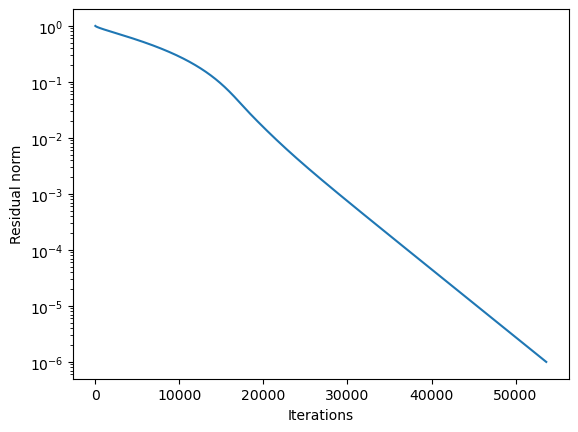

Python: Text(0.5, 24.0, 'Iterations')

In [127]:
aout=alg1e3(n; maxit=300000, tau0=.01, c=5.0, k=50.0, tol=1.e-6);
semilogy(aout.reshist); ylabel("Residual norm"); xlabel("Iterations")

For this example, I need a small stepsize to benefit from preconditioning.

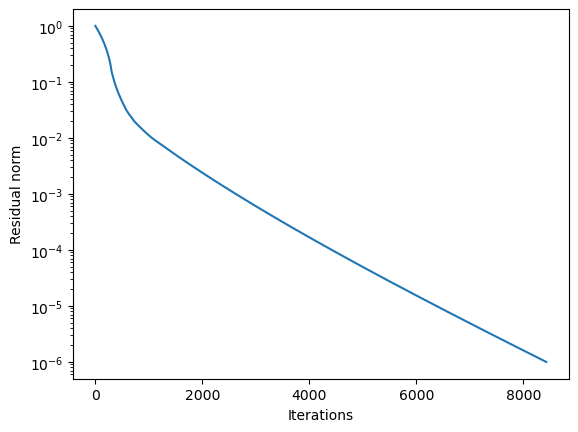

Python: Text(0.5, 24.0, 'Iterations')

In [128]:
aout=alg1e3(n; maxit=20000, tau0=.001, c=5.0, k=50.0, precond=true);
semilogy(aout.reshist); ylabel("Residual norm"); xlabel("Iterations")

You can see the dead core in the plot.

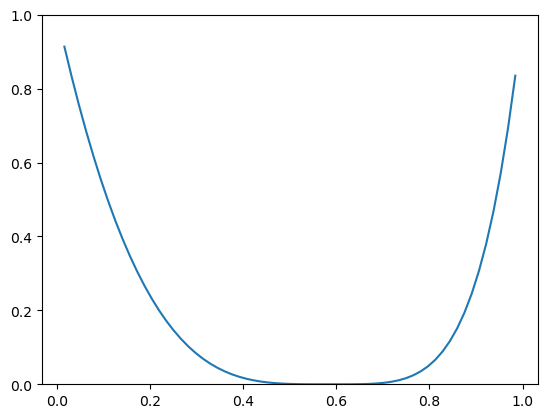

In [129]:
u1=aout.sol; plot(x,aout.sol); ylim([0.0, 1.0]);

I am not impressed with the look ahead method. Should we take it out? Can we find an example where the look ahead method does well?

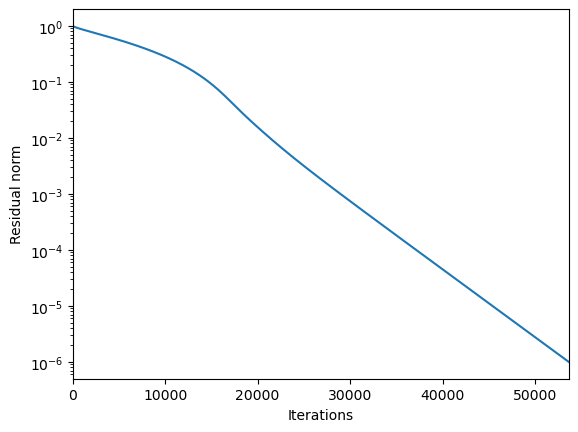

Python: (0.0, 53665.0)

In [130]:
aout=alg2ge3(n; maxit=300000, tau0=.01, c=5.0, k=50.0);
semilogy(aout.reshist); ylabel("Residual norm"); xlabel("Iterations");
PythonPlot.xlim(0.0,length(aout.reshist))

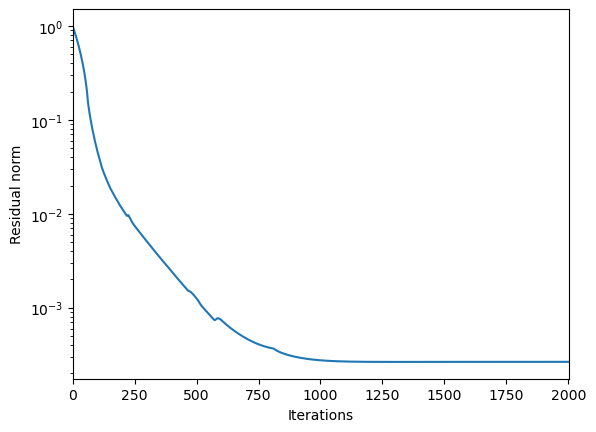

In [131]:
aout=alg2ge3(n; maxit=2000, tau0=.005, c=5.0, k=50.0, precond=true); lrh=length(aout.reshist)
semilogy(aout.reshist);
ylabel("Residual norm"); xlabel("Iterations");
PythonPlot.xlim(0.0,length(aout.reshist));

Our final example is to apply Anderson acceleration (AA) to this problem. AA is designed for fixed point problems of the form
$\bfu - \bfG(\bfu)$ and in this case we can use
$$
\bfG(\bfu) = \bfu - \bfF (\bfu) = \bfu - \bfL \bfu - c \bfD \bfu - \bfg.
$$
The preconditioned form is
$$
\bfG (\bfu) = \bfu - \bfL^{-1} \bfF(\bfu) = - \bfL^{-1} (c \bfD \bfu + \bfg)
$$
which is a discretized integral equation.

__Xaiojun, Lei, we could precondition with $(\bfL + c \bfD)^{-1}$. That would work much better but getting a fast solver in more than one space dimension would be a problem.__

AA does in fact converge more rapidly, but there does not seem to be any advantage to preconditioning and one has to tune $m$ and $\tau$
more that I would like.

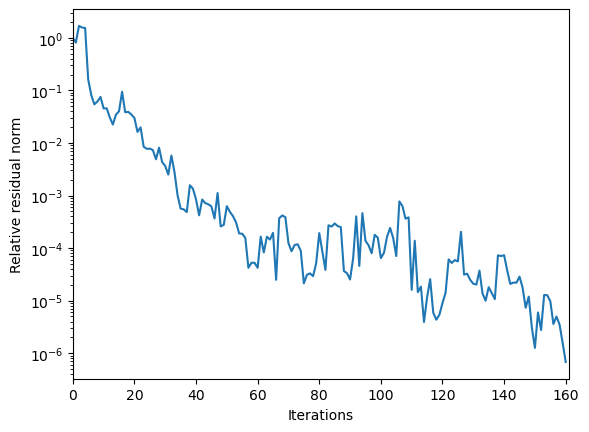

In [132]:
aout=aa_nonlip(n; GF=GF1e3!, tau=.05, m=4)
semilogy(aout.rhist/aout.rhist[1]); ylabel("Relative residual norm"); xlabel("Iterations");
PythonPlot.xlim(0.0,length(aout.rhist));

The unpreconditioned AA iteration seems to perform as well with a much smaller step. I need to keep working on this.

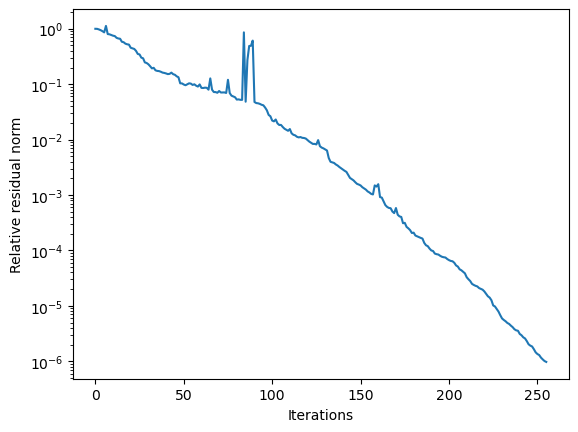

In [133]:
aout=aa_nonlip(n; GF=GF1e3!, precond=false, tau=.001, m=5, maxit=10000);
semilogy(aout.rhist/aout.rhist[1]); ylabel("Relative residual norm"); xlabel("Iterations");
#PythonPlot.xlim(0.0,length(aout.rhist));